In [4]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nNulls per column:\n", df.isnull().sum())

Shape: (200, 5)

Data types:
 CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Nulls per column:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [7]:
df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [12]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

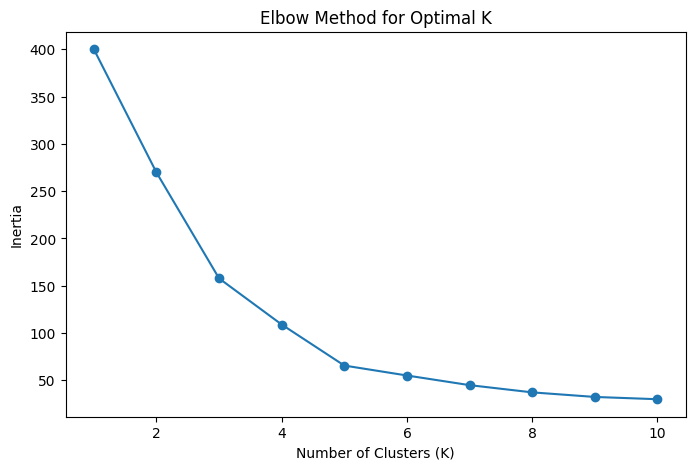

In [11]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

In [13]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


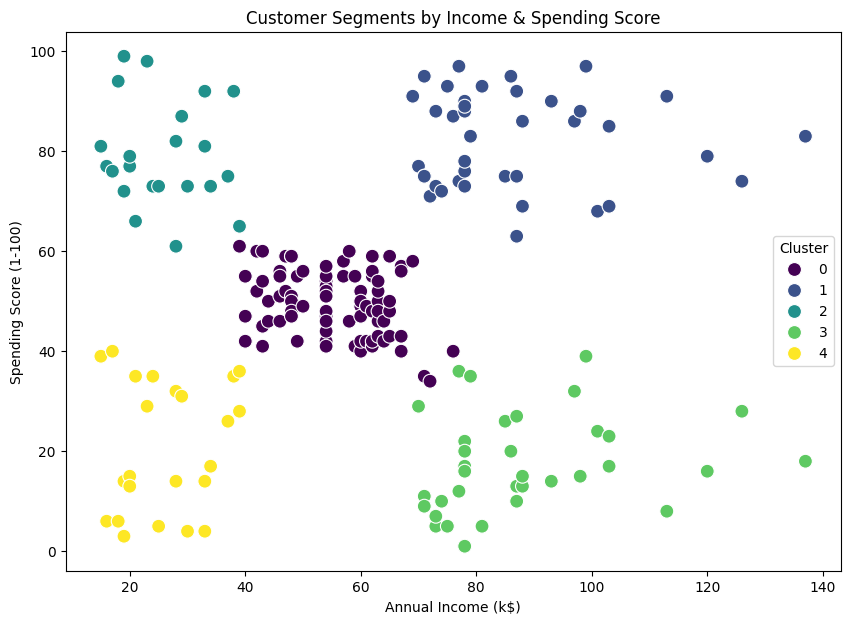

In [14]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='viridis',
    s=100
)
plt.title('Customer Segments by Income & Spending Score')
plt.show()

In [15]:
cluster_profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(cluster_profile)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043


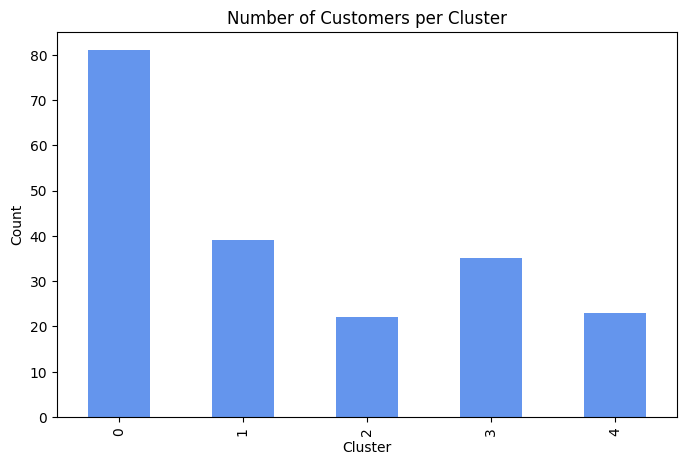

In [16]:
plt.figure(figsize=(8,5))
df['Cluster'].value_counts().sort_index().plot(kind='bar', color='cornflowerblue')
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

Cluster sizes: Cluster 0 (average income/spending) is the largest group by far (~80 customers), while the other four segments are more evenly distributed (30-45 customers each). This means most of the customer base falls into the "typical" middle range, but the smaller extreme segments especially high-value Cluster 1 still represent significant revenue given their higher spending scores.

# **Insights & Recommendations:**
Cluster 0 (Average, largest group): Broad-appeal campaigns and loyalty programs to nudge spending upward biggest audience, biggest opportunity for incremental gains.

Cluster 1 (High income, high spending): VIP treatment early access, premium loyalty perks, personalized offers. This is your most valuable segment; retention matters most here.

Cluster 2 (Low income, high spending): Budget-friendly bundles, installment/credit options, and flash sales they're already engaged, just need affordable ways to spend more.

Cluster 3 (High income, low spending): Investigate why likely need better targeting or premium product exposure. Personalized recommendations or exclusive previews could convert this untapped spending power.

Cluster 4 (Low income, low spending): Lowest priority for aggressive marketing spend — focus on low-cost engagement (email newsletters, occasional discounts) rather than heavy investment.